In [27]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [4]:
Main.eval('using Distributed')
Main.eval('addprocs(2)') 

array([2, 3], dtype=int64)

In [5]:
Main.eval("""
    @everywhere begin
        using Distributed
        using DelimitedFiles      
        df_LO = readdlm("fixed order/EECLO.csv", ',')
        df_NLO = readdlm("fixed order/EECNLO.csv", ',')
        df_NNLO = readdlm("fixed order/EECNNLO.csv", ',')
    end
""")

Main.include("strong coupling\\constants.jl")
Main.include("strong coupling\\alpha_s.jl")

Main.include("fixed order\\perturbative EEC.jl")
Main.include("fixed order\\SCET.jl")
Main.include("fixed order\\non-singular.jl")
Main.include("fixed order\\analytic.jl")

Main.include("Σb.jl")
Main.include("cross section.jl")
Main.include("NP.jl")
Main.include("parallel/fit.jl")

<PyCall.jlwrap model>

In [7]:
error_type = "both"

df_NNLO = pd.read_csv("fixed order/EECNNLO.csv",header=None)

def fixed_error_func(angle: float, df: pd.DataFrame) -> float:
    angles = df.iloc[:, 0]      
    errors = df.iloc[:, 2]       
    
    pos = np.abs(angles.values - angle).argmin()
    return float(errors.iloc[pos])

Data Selection

In [8]:
#-------------------------------------------------------------------
dataset_names = ["SLD","TOPAZ_595","TOPAZ_533",
                "TASSO_435","TASSO_348","MARKII","MAC"]
#-------------------------------------------------------------------
#dataset_names = ["SLD","TOPAZ_595","TOPAZ_533",
#                "TASSO_435","TASSO_348","MARKII"]
#-------------------------------------------------------------------
#dataset_names = ["OPAL_new"]

df = {}

for name in dataset_names:
    file_path = f"data/{name}.csv"
    df0 = pd.read_csv(file_path)
    
    χ = df0["CHI"]
    EEC = df0["EEC"]
    ERROR = df0["ERROR"]
    Q = df0["Q"]
    BinSize = df0["BinSize"]

    print(Q[0])

    if error_type == "both":
        
        αs = Main.alpha_s_func(μf=Q[0], μi=91.1876, αs=0.118, order=4, nf=5)
        a = αs/(2*np.pi)

        fixed_error=[]
        for angle in χ:
            value = (a**3)*fixed_error_func(angle=angle, df=df_NNLO)
            fixed_error.append(value)
        ERROR = np.sqrt(df0["ERROR"]**2 + np.array(fixed_error)**2)
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR, "Q": Q, "BinSize": BinSize})
    df[name] = df1

91.2
59.5
53.3
43.5
34.8
29.0
29.0


Kinematic Cut

In [9]:
cut_list = {}
cut_list["sqrtz"] = [0,1/2]
#cut_list["kt"] = []

In [10]:
df_truncated = {}

χ = {}
EEC = {}
ERROR = {}
Q = {}
BinSize = {}

for name in dataset_names:
    sqrtz_list = np.sqrt((1-np.cos(df[name]["CHI"]*np.pi/180))/2)
    kt_list = sqrtz_list*df[name]["Q"]

    if "sqrtz" in cut_list:
        sqrtz_lower, sqrtz_upper = cut_list["sqrtz"]
        df_truncated[name] = df[name][(sqrtz_list <= sqrtz_upper) & (sqrtz_list >= sqrtz_lower)]

    if "kt" in cut_list:
        χ_lower, χ_upper = cut_list["kt"]
        df_truncated[name] = df[name][(kt_list <= kt_upper) & (kt_list >= kt_lower)]

    if "χ" in cut_list:
        kt_lower, kt_upper = cut_list["kt"]
        df_truncated[name] = df[name][(df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]
    
    χ[name] = np.array(df_truncated[name]["CHI"])
    EEC[name] = np.array(df_truncated[name]["EEC"])
    ERROR[name] = np.array(df_truncated[name]["ERROR"])
    Q[name] = np.array(df_truncated[name]["Q"])
    BinSize[name] = np.array(df_truncated[name]["BinSize"])

#display(df_truncated)
for name in dataset_names:
    display(len(df_truncated[name]))

16

16

16

16

16

16

16

Chi-Square calculation

In [11]:
def DELTA_func(ylist,PRED):
    l = len(ylist)
    theory = np.zeros(l)
    for i in range(l):
        simpson = 1/12*(PRED[0][i] + 4*PRED[1][i] + 2*PRED[2][i] + 4*PRED[3][i] + PRED[4][i])
        theory[i] = np.nan_to_num(simpson,nan=0.0)
    return theory - ylist

def CHI2_func(DELTA,ERROR):
    chi_squared = np.sum(np.square(DELTA/ERROR))
    return chi_squared

import sys
def objective(params, df):

    #----------
    XLL = 2 #1 for NLL
    #----------

    N = 5
    
    chi2 = 0
    N_total = 0
    
    αs = params[0]
    params_noαs = params[1:]

    dataset_names = df.keys()

    for name in dataset_names:
        xlist={}
        xlist_mid = np.array(df[name]["CHI"])
        binsize = np.array(df[name]["BinSize"]) 
        for i in range(N):
            xlist[i]=xlist_mid-binsize/2+i*binsize/(N-1)

        ylist=np.array(df[name]["EEC"])
        ERROR_list=np.array(df[name]["ERROR"])

        data_size = len(xlist_mid)
        N_total = N_total + data_size

        PRED={}

        parameters = params_noαs
        for quartile in range(N):
            PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Qlist=np.array(df[name]["Q"]), order=XLL, params=parameters)                
        DELTA =  DELTA_func(ylist,PRED)                       

        chi_square = CHI2_func(DELTA,ERROR_list)
        chi2 = chi2 + chi_square

    return chi2/N_total

In [12]:
import csv
import sys

class ProgressCallback:
    def __init__(self, df, csv_file='record.csv'):
        self.df = df
        self.iteration = 0
        self.csv_file = csv_file

    def __call__(self, params):
        self.iteration += 1
        chi2_bydof = objective(params, self.df)
        
        print(f"Iteration: {self.iteration}, Params: {params}, Chi2/dof: {chi2_bydof}")
        sys.stdout.flush()

        with open(self.csv_file, mode='a', newline='') as file:
            writer = csv.writer(file)
            writer.writerow([self.iteration] + list(params) + [chi2_bydof])


class MyBounds:
    def __init__(self, xmax, xmin):
        self.xmax = np.array(xmax)
        self.xmin = np.array(xmin)

    def __call__(self, **kwargs):
        x = kwargs["x_new"]
        tmax = bool(np.all(x <= self.xmax))
        tmin = bool(np.all(x >= self.xmin))
        return tmax and tmin
    
if_renormalon = False

In [13]:
def set_NP(ansatz: str):
    body = ansatz

    julia_code = f"""
    @everywhere begin
        function NP(; z::Float64, b::Float64, ζi::Float64, ζf::Float64, params::Vector{{Float64}})
            a = params
            NP = {body}
            return NP
        end
    end
    """
    Main.eval(julia_code)

In [14]:
df_ansatzes = pd.DataFrame([
    {"ansatz": "a[1]*exp(-(a[2]*b^a[3]))", 
     "params": [0.118, 0.886, 2.67, 1.09]	},           
])

In [15]:
for nth in range(len(df_ansatzes)):
    set_NP(df_ansatzes["ansatz"].iloc[nth])
    chi2 = objective(df_ansatzes["params"].iloc[nth], df_truncated)
    print(chi2)

2.0529953619261234


In [16]:
def round_sig(x, sig=3):
    if isinstance(x, np.ndarray):
        return np.array([round_sig(val, sig) for val in x])
    elif isinstance(x, list):
        return [round_sig(val, sig) for val in x]
    elif x == 0:
        return 0
    else:
        return round(x, sig - int(np.floor(np.log10(abs(x)))) - 1)

Local then hopping

In [17]:
sqrtz_upper_list = [0.3,0.4,0.5,0.6,0.7]
#sqrtz_upper_list = []
kt_upper_list = []
#kt_upper_list = []

In [18]:
from itertools import product

cut_list = []
for sqrtz_upper, kt_upper in product(
        sqrtz_upper_list or [None],
        kt_upper_list    or [None],
):
    cuts = {}
    if sqrtz_upper is not None:
        cuts["sqrtz"] = [0, round_sig(sqrtz_upper)]
    if kt_upper    is not None:
        cuts["kt"]    = [0, round_sig(kt_upper)]
    cut_list.append(cuts)
cut_list

[{'sqrtz': [0, 0.3]},
 {'sqrtz': [0, 0.4]},
 {'sqrtz': [0, 0.5]},
 {'sqrtz': [0, 0.6]},
 {'sqrtz': [0, 0.7]}]

In [19]:
result_df = pd.DataFrame(columns=["N", "ansatz", "cut", "params", "χ2/N"])

for nth in range(len(df_ansatzes)):
    for cuts in cut_list:
        set_NP(df_ansatzes["ansatz"].iloc[nth])

        df_truncated = {}
        χ = {}
        EEC = {}
        ERROR = {}

        N_total = 0
        for name in dataset_names:
            sqrtz_list = np.sqrt((1-np.cos(df[name]["CHI"]*np.pi/180))/2)
            kt_list = sqrtz_list*df[name]["Q"]

            if "sqrtz" in cuts:
                sqrtz_lower, sqrtz_upper = cuts["sqrtz"]
                df_truncated[name] = df[name][(sqrtz_list <= sqrtz_upper) & (sqrtz_list >= sqrtz_lower)]

            if "kt" in cuts:
                kt_lower, kt_upper = cuts["kt"]
                df_truncated[name] = df[name][(kt_list <= kt_upper) & (kt_list >= kt_lower)]

            if "χ" in cuts:
                χ_lower, χ_upper = cuts["χ"]
                df_truncated[name] = df[name][(df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]
            
            N_total = N_total + len(df_truncated[name]["CHI"])

        initial_params = df_ansatzes["params"].iloc[nth]

        bounds = []
        bounds.append([0.118,0.118])
        bounds.append([0.0,10.0])
        bounds.append([0.0,10.0])                                                                                
        for i in range(len(initial_params)-3):
            bounds.append([-10.0, 10.0])

            bounds_T = [list(t) for t in zip(*bounds)]

        progress_callback = ProgressCallback(df_truncated)

        minimizer_kwargs = {
            "method": "L-BFGS-B",
            "bounds": bounds,
            "args": (df_truncated),
            "options": {'maxiter': 100, 'disp': True, "ftol": 10**(-12)},
            "callback": progress_callback
        }

        result = basinhopping(
            objective,
            initial_params,
            minimizer_kwargs=minimizer_kwargs,
            niter=0,
            accept_test=MyBounds(xmax=bounds_T[1],xmin=bounds_T[0])
        )

        optimal_params = result.x                        
        result_df.loc[len(result_df)] = [N_total, df_ansatzes["ansatz"].iloc[nth], cuts, round_sig(optimal_params), round_sig(result.fun)]

result_df.to_csv("result.csv", index=False)
display(result_df)

Iteration: 1, Params: [0.118      0.88309259 2.66123838 1.11923821], Chi2/dof: 2.2675304957606417
Iteration: 2, Params: [0.118      0.85872506 2.65338016 1.14276878], Chi2/dof: 1.693601003546548
Iteration: 3, Params: [0.118      0.85792458 2.6546017  1.14221644], Chi2/dof: 1.689813148029171
Iteration: 4, Params: [0.118      0.8571895  2.65733455 1.14192824], Chi2/dof: 1.6850954758243457
Iteration: 5, Params: [0.118      0.85573823 2.66574415 1.14261177], Chi2/dof: 1.673048950232808
Iteration: 6, Params: [0.118      0.85321066 2.68651135 1.14621709], Chi2/dof: 1.646970009004939
Iteration: 7, Params: [0.118      0.84978391 2.72587127 1.15533779], Chi2/dof: 1.6033351520343817
Iteration: 8, Params: [0.118      0.84749216 2.77095093 1.16831438], Chi2/dof: 1.5593258286671197
Iteration: 9, Params: [0.118      0.84769299 2.78817757 1.17498641], Chi2/dof: 1.545667567334688
Iteration: 10, Params: [0.118      0.84825083 2.78615209 1.17551555], Chi2/dof: 1.5444798727601052
Iteration: 11, Params: [

,N,ansatz,cut,params,χ2/N
0,63,a[1]*exp(-(a[2]*b^a[3])),"{'sqrtz': [0, 0.3]}","[0.118, 0.848, 2.78, 1.18]",1.54
1,84,a[1]*exp(-(a[2]*b^a[3])),"{'sqrtz': [0, 0.4]}","[0.118, 0.855, 2.77, 1.16]",1.48
2,112,a[1]*exp(-(a[2]*b^a[3])),"{'sqrtz': [0, 0.5]}","[0.118, 0.865, 2.73, 1.14]",1.57
3,133,a[1]*exp(-(a[2]*b^a[3])),"{'sqrtz': [0, 0.6]}","[0.118, 0.873, 2.7, 1.11]",1.73
4,168,a[1]*exp(-(a[2]*b^a[3])),"{'sqrtz': [0, 0.7]}","[0.118, 0.887, 2.62, 1.07]",2.65


In [20]:
Main.eval('rmprocs(workers())')

<PyCall.jlwrap Task (runnable) @0x0000027995a6e6d0>

Plot

In [21]:
NLL = 2
χ_low = 0.1
χ_up = 60.0
kt_lower = 0
kt_upper = 100
sqrtz_cut = 1/2
optimal_params= [0.122, 0.886, 2.67, 1.09]

In [22]:
Q_list = {}
Q_list["SLD"]       = 91.2
Q_list["OPAL"]      = 91.2
Q_list["OPAL_new"]  = 91.2
Q_list["DELPHI"]    = 91.2
Q_list["TOPAZ_595"] = 59.5
Q_list["TOPAZ_533"] = 53.3
Q_list["TASSO_435"] = 43.5
Q_list["TASSO_348"] = 34.8
Q_list["MARKII"]    = 29.0
Q_list["MAC"]       = 29.0
Q_list["TASSO_220"] = 22.0
Q_list["TASSO_140"] = 14.0

In [30]:
N_points = 200

xlist = np.linspace(χ_low, χ_up, N_points, endpoint=True)
length=len(xlist)

αs=optimal_params[0]
params_noαs = optimal_params[1:]
print(params_noαs)

v={}
non_singular = {}

for name in dataset_names:
    
    Qlist = Q_list[name]*np.ones(N_points)

    parameters = params_noαs
    if len(parameters) > 0:
        v[name] = Main.model(Qlist=Qlist, xlist=xlist, αs=αs, order=NLL, params=parameters)
    else:
        v[name] = Main.model(Qlist=Qlist, xlist=xlist, αs=αs, order=NLL)      

[0.886, 2.67, 1.09]


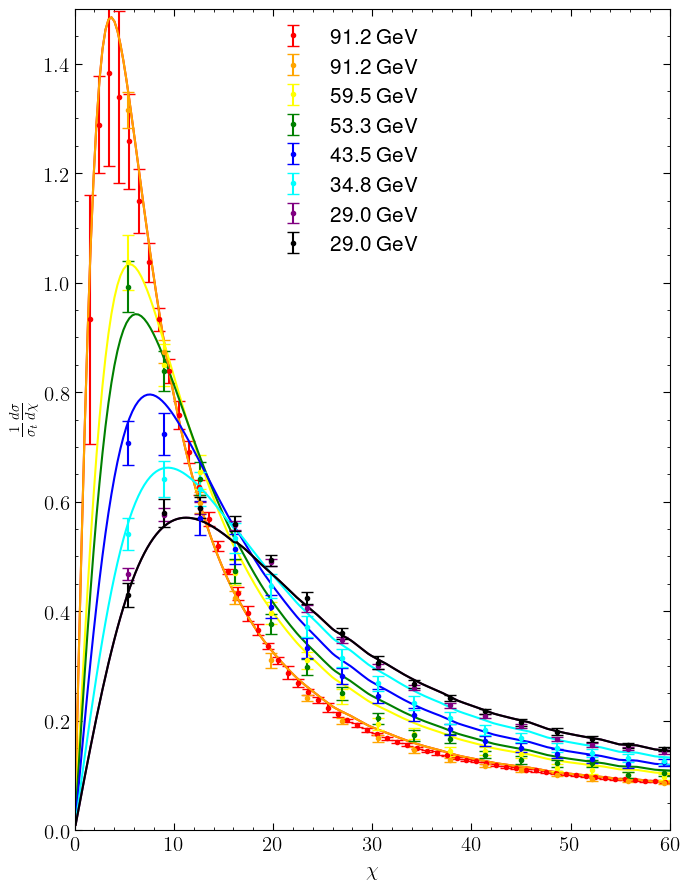

In [31]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 9)) 

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","yellow","green","blue","cyan","purple","black","yellow","orange"]
i=0
for name in dataset_names:
    ax1.errorbar(df_truncated[name]["CHI"], df_truncated[name]["EEC"], df_truncated[name]["ERROR"], fmt='o',label=str(Q_list[name]) + " GeV", color=color[i], capsize=4,markersize=3)
    ax1.plot(xlist, v[name], color=color[i])
    i=i+1

ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_t} \frac{d \sigma}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.3, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
#ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
#verticalalignment='top', bbox=props)

plt.ylim(0.0,1.5)
plt.xlim(0.0,χ_up)

plt.tight_layout()  
plt.show()

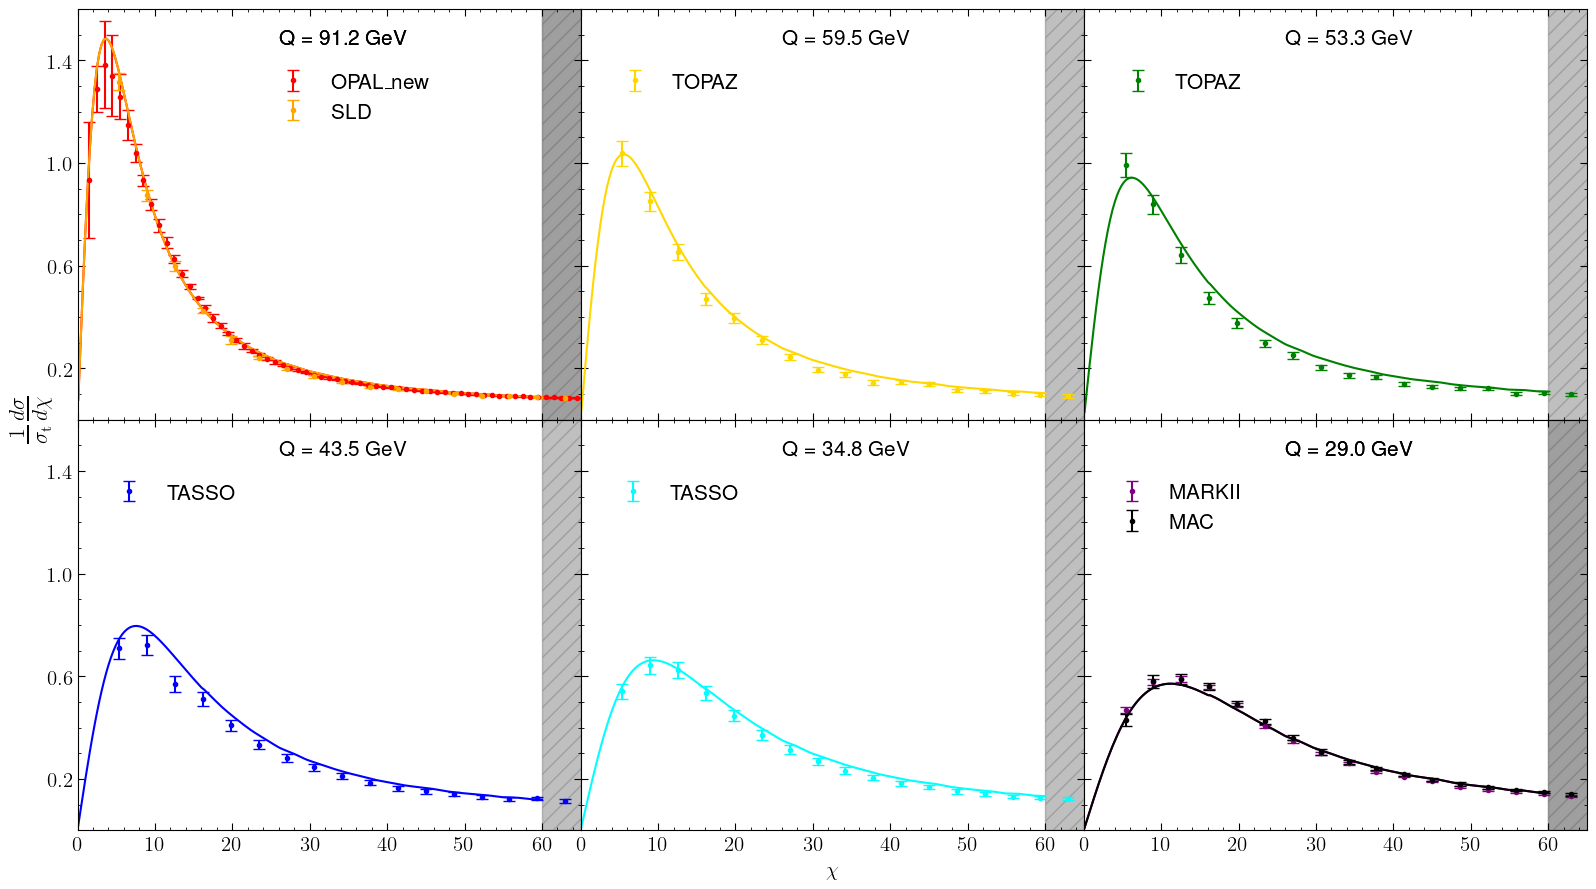

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","gold","green","blue","cyan","purple","black","yellow","green"]
ax_list = [ax1,ax2,ax3,ax4,ax5,ax6]
Q_set = [91.2,59.5,53.3,43.5,34.8,29.0,22.0,14.0]

name_set = {}
name_set["SLD"]       = "SLD"
name_set["OPAL"]      = "OPAL"
name_set["OPAL_new"]      = "OPAL_new"
name_set["DELPHI"]    = "DELPHI"
name_set["TOPAZ_595"] = "TOPAZ"
name_set["TOPAZ_533"] = "TOPAZ"
name_set["TASSO_435"] = "TASSO"
name_set["TASSO_348"] = "TASSO"
name_set["MARKII"]    = "MARKII"
name_set["MAC"]       = "MAC"
name_set["TASSO_220"] = "TASSO"
name_set["TASSO_140"] = "TASSO"

i=0
j=0
for Q in Q_set:
    for name in dataset_names:
        if Q_list[name]==Q:
            ax_list[i].errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o',label=str(name_set[name]), color=color[j], capsize=4,markersize=3)
            ax_list[i].plot(xlist, v[name], color=color[j])
            ax_list[i].text(0.4, 0.95, "Q = " + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
            #χ_peak = np.arccos(1-2*(kt_lower/Q_list[name])**2)*180/np.pi
            χ_peak = np.arccos(1-2*(sqrtz_cut)**2)*180/np.pi
            #ax_list[i].axvline(x=χ_peak, color='black', linestyle='--')
            ax_list[i].axvspan(χ_peak, 90, color='gray', alpha=0.5, hatch='//')
            j=j+1
    i=i+1

ax5.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{d \sigma}{d \chi}$",fontsize=1.5*sizeOfFont)
ax1.yaxis.set_label_coords(-0.05,0.0)
for ax in ax_list:
    ax.legend()
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.35, 0.89))
    #ax.axvline(x=χ_upper)

props = dict(boxstyle='round', facecolor='white', alpha=0)

plt.ylim(0.0, 1.6)
plt.yticks([0.2,0.6,1.0,1.4])

plt.xlim(0,65)

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()

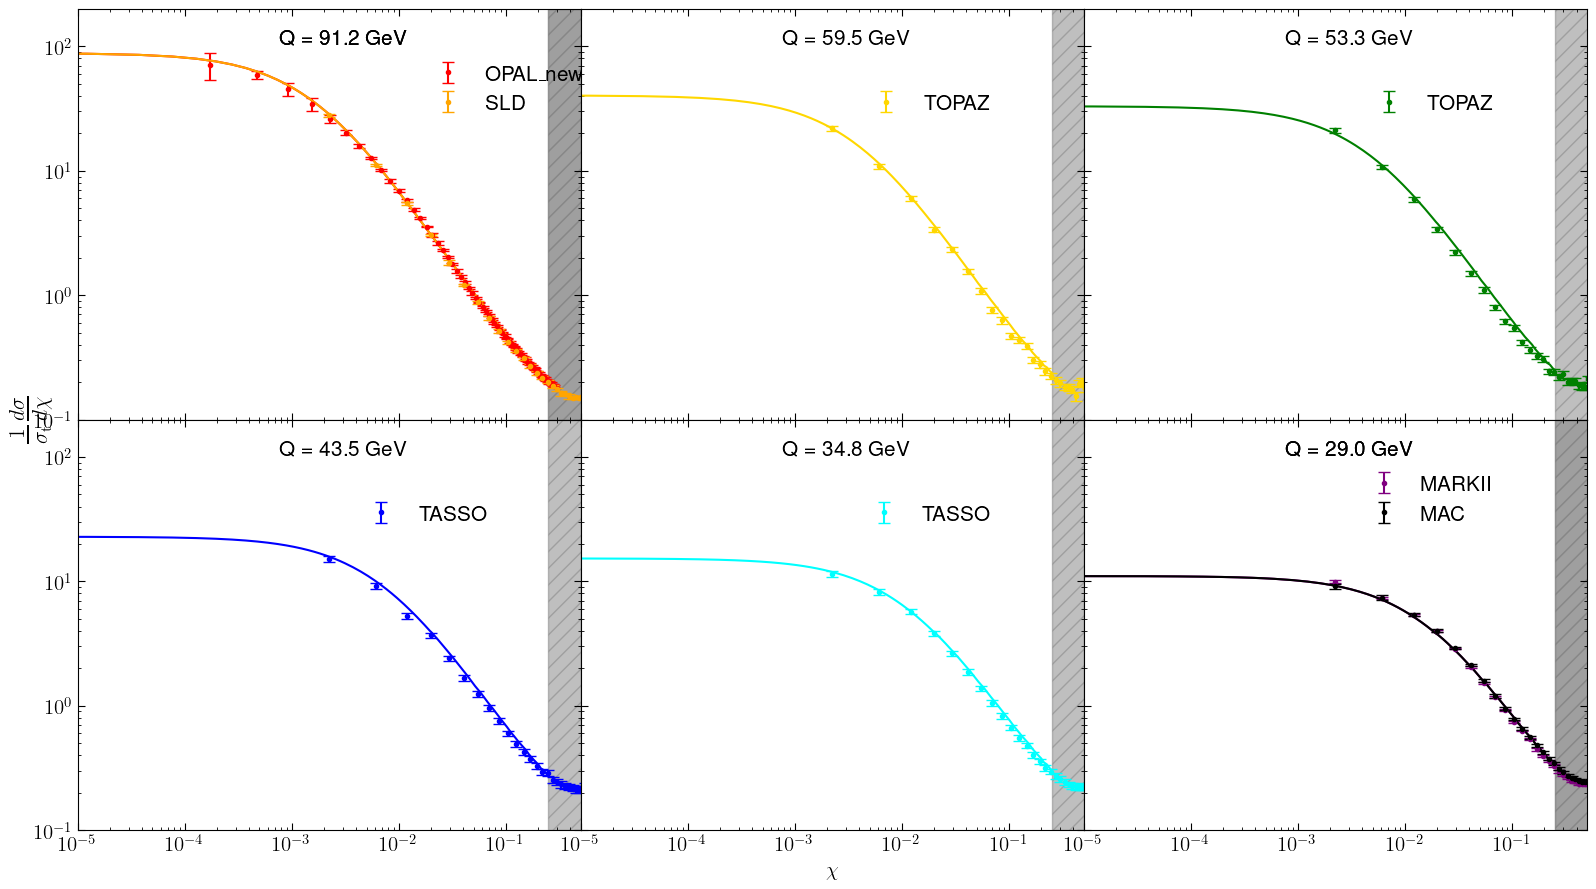

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","gold","green","blue","cyan","purple","black","yellow","green"]
ax_list = [ax1,ax2,ax3,ax4,ax5,ax6]
Q_set = [91.2,59.5,53.3,43.5,34.8,29.0,22.0,14.0]

name_set = {}
name_set["SLD"]       = "SLD"
name_set["OPAL"]      = "OPAL"
name_set["OPAL_new"]      = "OPAL_new"
name_set["DELPHI"]    = "DELPHI"
name_set["TOPAZ_595"] = "TOPAZ"
name_set["TOPAZ_533"] = "TOPAZ"
name_set["TASSO_435"] = "TASSO"
name_set["TASSO_348"] = "TASSO"
name_set["MARKII"]    = "MARKII"
name_set["MAC"]       = "MAC"
name_set["TASSO_220"] = "TASSO"
name_set["TASSO_140"] = "TASSO"

i=0
j=0

predictionz={}

for Q in Q_set:
    for name in dataset_names:

        df[name]["z"] = (1-np.cos(df[name]["CHI"]*np.pi/180))/2
        df[name]["EECz"] = 2/np.sin(df[name]["CHI"]*np.pi/180)*df[name]["EEC"]
        df[name]["ERRORz"] = 2/np.sin(df[name]["CHI"]*np.pi/180)*df[name]["ERROR"]       
        predictionz[name] = 2/np.sin(xlist*np.pi/180)*(v[name])
        zlist = (1-np.cos(xlist*np.pi/180))/2

        if Q_list[name]==Q:
            ax_list[i].errorbar(df[name]["z"], df[name]["EECz"], df[name]["ERRORz"], fmt='o',label=str(name_set[name]), color=color[j], capsize=4,markersize=3)
            ax_list[i].plot(zlist, predictionz[name], color=color[j])
            ax_list[i].text(0.4, 0.95, "Q = " + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
            z_peak = sqrtz_cut**2
            ax_list[i].axvspan(z_peak, 1, color='gray', alpha=0.5, hatch='//')
            j=j+1
    i=i+1

ax5.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{d \sigma}{d \chi}$",fontsize=1.5*sizeOfFont)
ax1.yaxis.set_label_coords(-0.05,0.0)
for ax in ax_list:
    ax.legend()
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.85, 0.7))
    #ax.axvline(x=χ_upper)

props = dict(boxstyle='round', facecolor='white', alpha=0)

plt.ylim(0.1, 200.0)
#plt.yticks([0.2,0.6,1.0,1.4])

plt.xlim(0.00001,0.5)
plt.xscale("log")
plt.yscale("log")

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()

In [34]:
average_error={}

for name in dataset_names:
    l = len(χ[name])
    average_error[name]=round(np.sum(df_truncated[name]["ERROR"]**2)**0.5/l,4)

display(average_error)

{'OPAL_new': 0.0061,
 'SLD': 0.0031,
 'TOPAZ_595': 0.0051,
 'TOPAZ_533': 0.0048,
 'TASSO_435': 0.0051,
 'TASSO_348': 0.0047,
 'MARKII': 0.0017,
 'MAC': 0.0031}

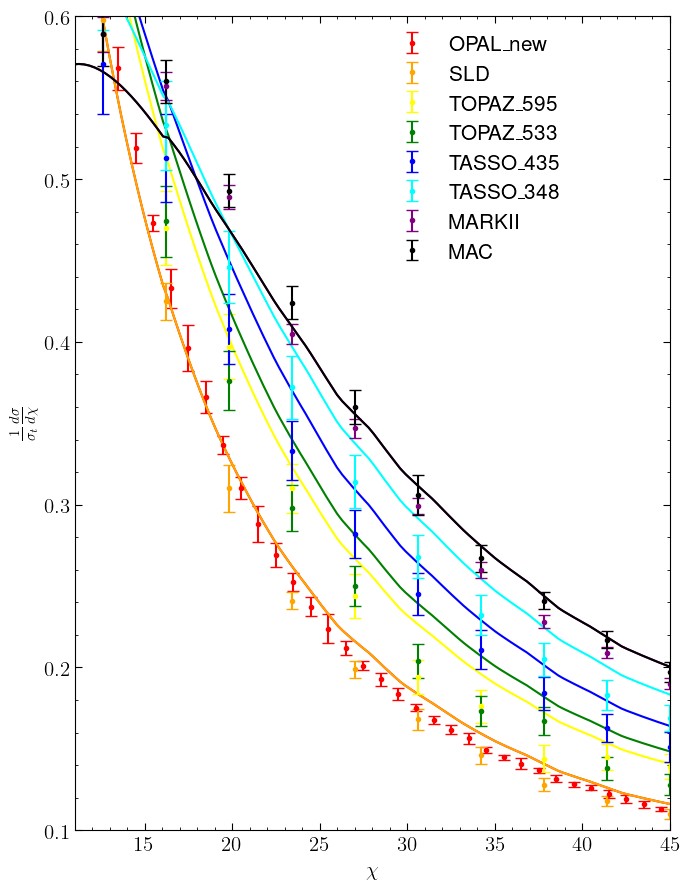

In [35]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 9)) 

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","yellow","green","blue","cyan","purple","black","yellow","orange"]
i=0
for name in dataset_names:
    ax1.errorbar(df_truncated[name]["CHI"], df_truncated[name]["EEC"], df_truncated[name]["ERROR"], fmt='o',label=str(name), color=color[i], capsize=4,markersize=3)
    ax1.plot(xlist, v[name], color=color[i])
    i=i+1

ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_t} \frac{d \sigma}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.5, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
#ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
#verticalalignment='top', bbox=props)

plt.ylim(0.1,0.6)
plt.xlim(11.0,45)

plt.tight_layout()  
plt.show()

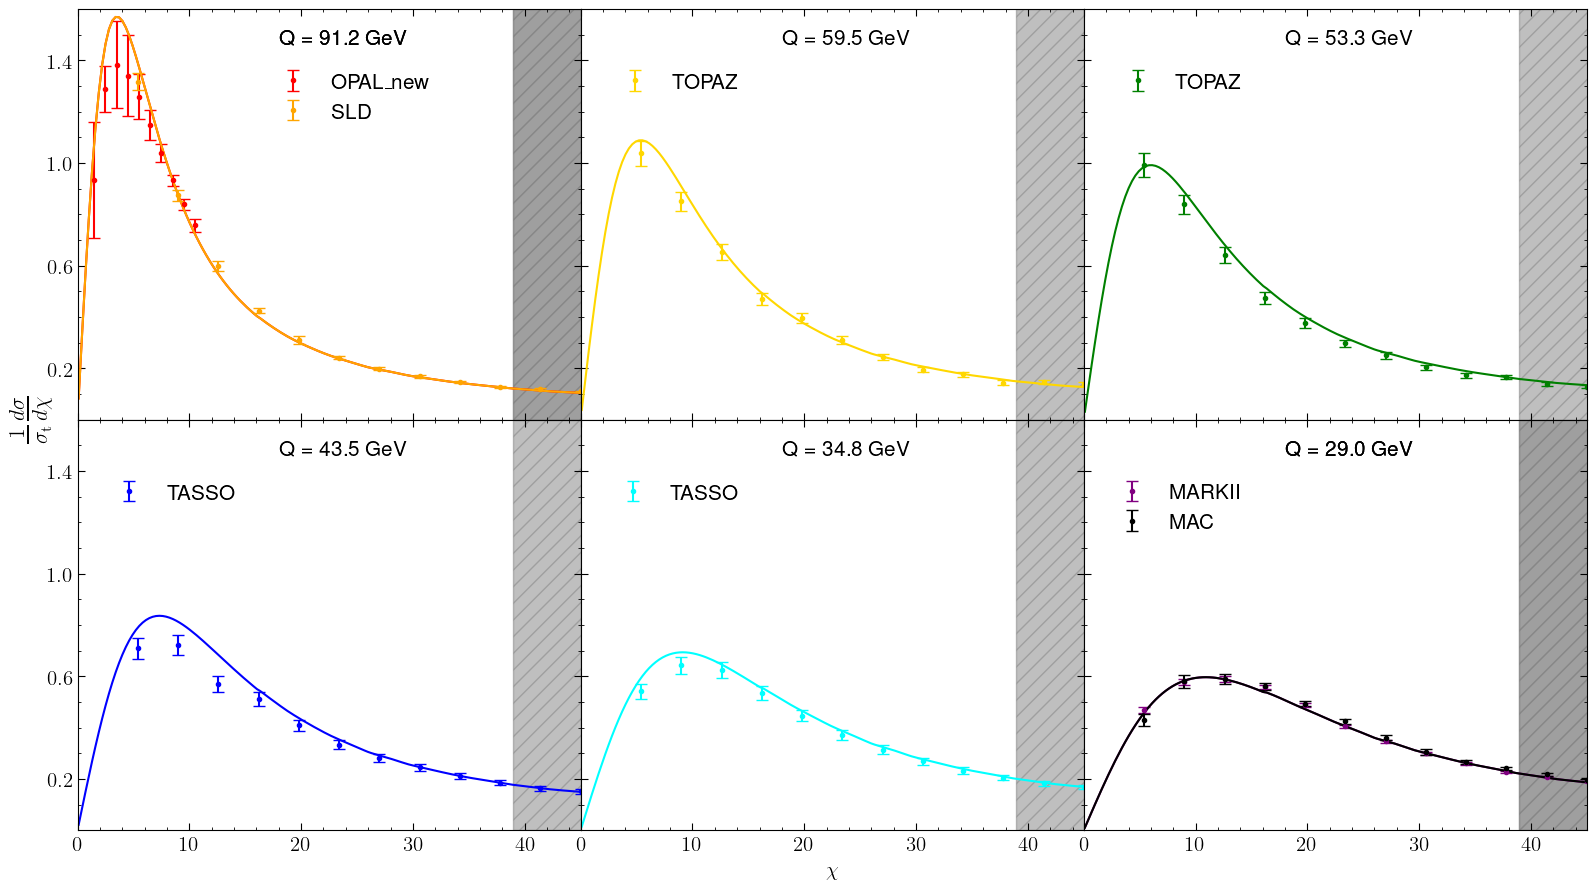

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","gold","green","blue","cyan","purple","black","yellow","green"]
ax_list = [ax1,ax2,ax3,ax4,ax5,ax6]
Q_set = [91.2,59.5,53.3,43.5,34.8,29.0,22.0,14.0]

name_set = {}
name_set["SLD"]       = "SLD"
name_set["OPAL"]      = "OPAL"
name_set["OPAL_new"]      = "OPAL_new"
name_set["DELPHI"]    = "DELPHI"
name_set["TOPAZ_595"] = "TOPAZ"
name_set["TOPAZ_533"] = "TOPAZ"
name_set["TASSO_435"] = "TASSO"
name_set["TASSO_348"] = "TASSO"
name_set["MARKII"]    = "MARKII"
name_set["MAC"]       = "MAC"
name_set["TASSO_220"] = "TASSO"
name_set["TASSO_140"] = "TASSO"

i=0
j=0
for Q in Q_set:
    for name in dataset_names:
        if Q_list[name]==Q:
            if name == "OPAL_new":
                ax_list[i].errorbar(df[name]["CHI"][0:10], df[name]["EEC"][0:10], df[name]["ERROR"][0:10], fmt='o',label=str(name_set[name]), color=color[j], capsize=4,markersize=3)
                ax_list[i].plot(xlist, v[name], color=color[j])
                ax_list[i].text(0.4, 0.95, "Q = " + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
                #χ_peak = np.arccos(1-2*(kt_lower/Q_list[name])**2)*180/np.pi
                χ_peak = np.arccos(1-2*(sqrtz_cut)**2)*180/np.pi
                #ax_list[i].axvline(x=χ_peak, color='black', linestyle='--')
                ax_list[i].axvspan(χ_peak, 90, color='gray', alpha=0.5, hatch='//')
                j=j+1                
            else:
                ax_list[i].errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o',label=str(name_set[name]), color=color[j], capsize=4,markersize=3)
                ax_list[i].plot(xlist, v[name], color=color[j])
                ax_list[i].text(0.4, 0.95, "Q = " + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
                #χ_peak = np.arccos(1-2*(kt_lower/Q_list[name])**2)*180/np.pi
                χ_peak = np.arccos(1-2*(sqrtz_cut)**2)*180/np.pi
                #ax_list[i].axvline(x=χ_peak, color='black', linestyle='--')
                ax_list[i].axvspan(χ_peak, 90, color='gray', alpha=0.5, hatch='//')
                j=j+1
    i=i+1

ax5.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{d \sigma}{d \chi}$",fontsize=1.5*sizeOfFont)
ax1.yaxis.set_label_coords(-0.05,0.0)
for ax in ax_list:
    ax.legend()
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.35, 0.89))
    #ax.axvline(x=χ_upper)

props = dict(boxstyle='round', facecolor='white', alpha=0)

plt.ylim(0.0, 1.6)
plt.yticks([0.2,0.6,1.0,1.4])

plt.xlim(0,45)

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()

In [24]:
NLL = 2
χ_low = 0.1
χ_up = 70.0
kt_lower = 0
kt_upper = 100
sqrtz_cut = 1/2
optimal_params_list= [
    [0.118, 0.848, 2.78, 1.18],
    [0.118, 0.855, 2.77, 1.16],
    [0.118, 0.865, 2.73, 1.14],
    [0.118, 0.873, 2.7, 1.11],
    [0.118, 0.887, 2.62, 1.07]		
]

In [40]:
N_points = 100

xlist = np.linspace(χ_low, χ_up, N_points, endpoint=True)
length=len(xlist)

v_list=[]
for optimal_params in optimal_params_list:
    αs=optimal_params[0]
    params_noαs = optimal_params[1:]
    print(params_noαs)

    v={}
    non_singular = {}
    for name in dataset_names:
        
        Qlist = Q_list[name]*np.ones(N_points)

        parameters = params_noαs
        v[name] = Main.model(Qlist=Qlist, xlist=xlist, αs=αs, order=NLL, params=parameters)
    v_list.append(v)

[0.848, 2.78, 1.18]
[0.855, 2.77, 1.16]
[0.865, 2.73, 1.14]
[0.873, 2.7, 1.11]
[0.887, 2.62, 1.07]


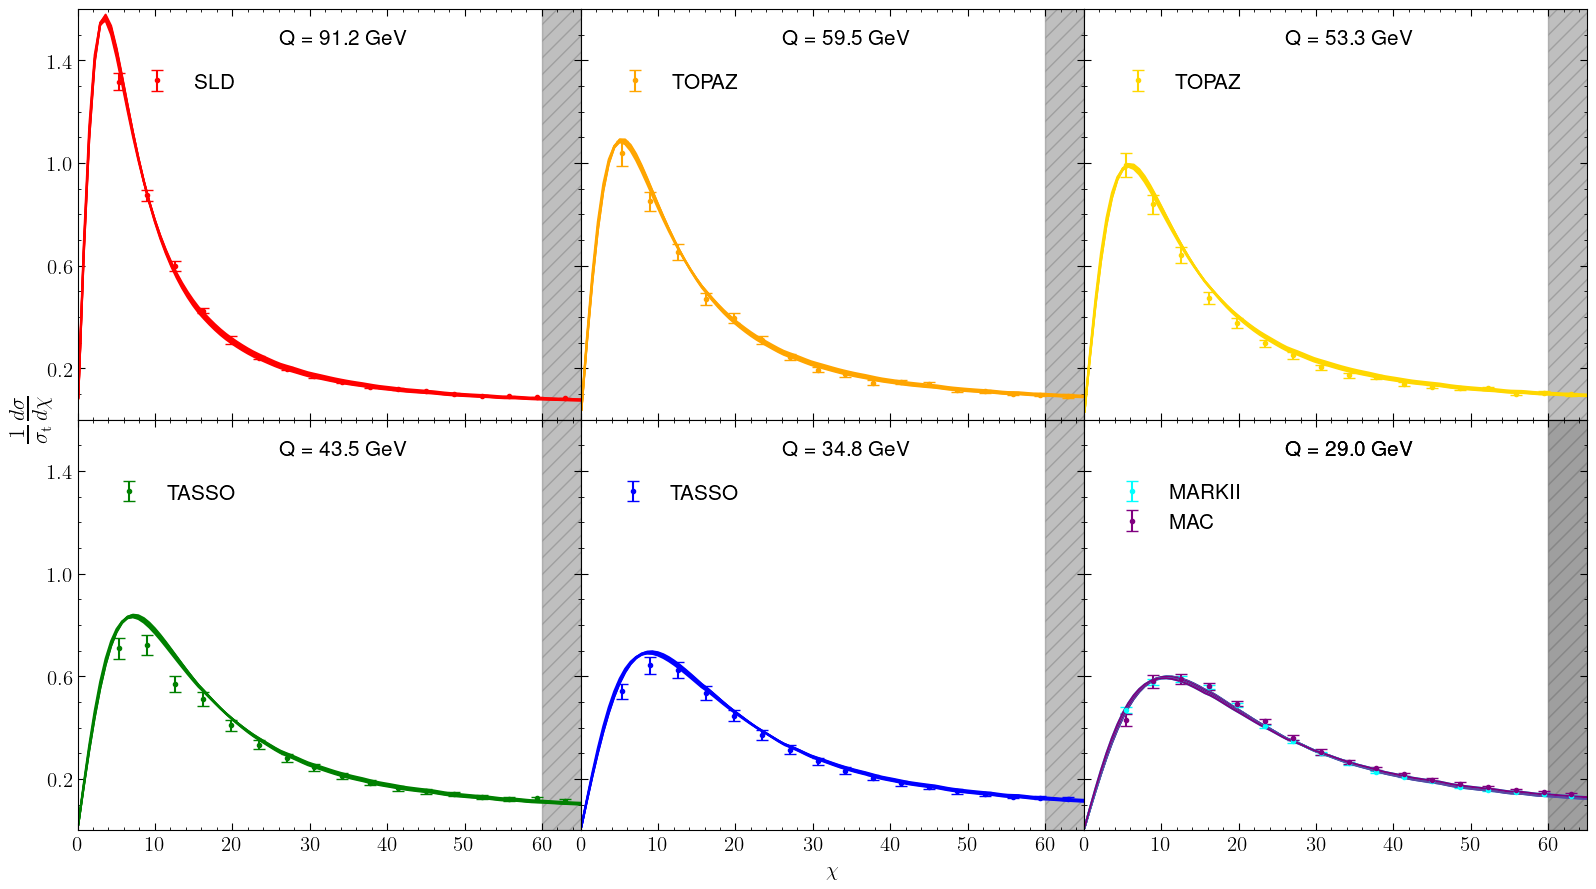

In [41]:
props = dict(boxstyle='round', facecolor='white', alpha=0)

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","gold","green","blue","cyan","purple","black","yellow","green"]
ax_list = [ax1,ax2,ax3,ax4,ax5,ax6]
Q_set = [91.2,59.5,53.3,43.5,34.8,29.0,22.0,14.0]

name_set = {}
name_set["SLD"]       = "SLD"
name_set["OPAL"]      = "OPAL"
name_set["OPAL_new"]      = "OPAL_new"
name_set["DELPHI"]    = "DELPHI"
name_set["TOPAZ_595"] = "TOPAZ"
name_set["TOPAZ_533"] = "TOPAZ"
name_set["TASSO_435"] = "TASSO"
name_set["TASSO_348"] = "TASSO"
name_set["MARKII"]    = "MARKII"
name_set["MAC"]       = "MAC"
name_set["TASSO_220"] = "TASSO"
name_set["TASSO_140"] = "TASSO"

i=0
j=0
for Q in Q_set:
    for name in dataset_names:
        if Q_list[name]==Q:
            ax_list[i].errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o',label=str(name_set[name]), color=color[j], capsize=4,markersize=3)
            ax_list[i].text(0.4, 0.95, "Q = " + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
            #χ_peak = np.arccos(1-2*(kt_lower/Q_list[name])**2)*180/np.pi
            χ_peak = np.arccos(1-2*(sqrtz_cut)**2)*180/np.pi
            #ax_list[i].axvline(x=χ_peak, color='black', linestyle='--')
            ax_list[i].axvspan(χ_peak, 90, color='gray', alpha=0.5, hatch='//')
            j=j+1
    i=i+1

for n in range(5):
    i=0
    j=0
    for Q in Q_set:
        for name in dataset_names:
            if Q_list[name]==Q:
                ax_list[i].plot(xlist, v_list[n][name], color=color[j])
                j=j+1
        i=i+1

ax5.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{d \sigma}{d \chi}$",fontsize=1.5*sizeOfFont)
ax1.yaxis.set_label_coords(-0.05,0.0)
for ax in ax_list:
    ax.legend()
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.35, 0.89))
    #ax.axvline(x=χ_upper)

plt.ylim(0.0, 1.6)
plt.yticks([0.2,0.6,1.0,1.4])

plt.xlim(0,65)

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()